# **Early Detection of Heart Disease Prediction**

# Made By - [Yuvraj Sharma](https://github.com/uvee3t) and [Ranadip Manna](https://github.com/RanadipM/Machine_Learning_Projects.)

# Objective

The objective of this project is to perform exploratory data analysis, preprocess the dataset, and build and evaluate machine learning models (KNeighbors Classifier, Decision Tree Classifier, and Random Forest Classifier) to predict the presence of heart disease based on the provided clinical data.

## Introduction

---



This project aims to predict the likelihood of heart disease in patients based on various clinical factors. We will explore the dataset, prepare it for machine learning, and then build and evaluate different classification models to achieve this objective.

Over the last few decades, heart disease is the most common cause of global death. So early detection of heart disease and continuous monitoring can reduce the mortality rate. The exponential growth of data from different sources such as wearable sensor devices used in Internet of Things health monitoring, streaming system and others have been generating an enormous amount of data on a continuous basis. The combination of streaming big data analytics and machine learning is a breakthrough technology that can have a significant impact in healthcare field especially early detection of heart disease. This technology can be more powerful and less expensive. To overcome this issue,realtime heart disease prediction system based on apache Spark/ real time input data which stand as a strong large scale distributed computing platform that can be used successfully for streaming data event against machine learning through in-memory computations.

# The Dataset used in this project is available on the UCI machine learning Repository.

It can be found at: https://archive.ics.uci.edu/ml/datasets/heart+disease. It consists of 303 different examples spread over 14 classes. Of the 303 examples, 165 are of "normal" people. We have 13 features, which include age, sex, Thal, CP of patients and other related information.

In [ ]:
# Importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif # Import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
# Loading the dataset
df = pd.read_csv('heart.csv')

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
# Returns number of rows and columns of the dataset
df.shape

(303, 14)

In [ ]:
# Returns an object with all of the column headers
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
# Returns different datatypes for each columns (float, int, string, bool, etc.)
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
# Returns the first x number of rows when head(x). Without a number it returns 5
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Returns the last x number of rows when tail(x). Without a number it returns 5
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [ ]:
# Returns true for a column having null values, else false
df.isnull().any()

,0
age,False
sex,False
cp,False
trestbps,False
chol,False
fbs,False
restecg,False
thalach,False
exang,False
oldpeak,False


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Returns basic information on all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


# Basic statistics on numeric columns

In [ ]:
# Returns basic statistics on numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


# Exploratory Data Analysis

Let's start by exploring the dataset to understand its structure and content.

# Data Visualization

In [ ]:
# Importing essential libraries
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
import plotly.express as px
import pandas as pd

# Create crosstab
age_target = pd.crosstab(df.age, df.target).reset_index()

# Convert to long format for plotly
age_target_long = age_target.melt(id_vars='age',
                                  value_vars=[0, 1],
                                  var_name='target',
                                  value_name='frequency')

# Plotly bar chart
fig = px.bar(
    age_target_long,
    x="age",
    y="frequency",
    color="target",
    barmode="group",
    title="Heart Disease Frequency for Ages",
)

fig.update_layout(
    xaxis_title="Age",
    yaxis_title="Frequency",
    width=1100,
    height=500
)

fig.show()


In [ ]:
import plotly.express as px

fig = px.histogram(df, x='age', color='target', marginal='box', # 'box' adds box plots to the margins
                   title='Distribution of Age by Heart Disease Status',
                   labels={'age': 'Age', 'target': 'Heart Disease'},
                   height=500,
                   hover_data=df.columns)

fig.update_layout(
    bargap=0.1, # Gap between bars
    xaxis_title='Age',
    yaxis_title='Count',
    legend_title='Heart Disease',
    title_x=0.5
)

fig.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure

In [ ]:
import plotly.express as px

# Use only numeric columns (pair plot works on numeric data)
num_df = df.select_dtypes(include='number')

fig = px.scatter_matrix(
    num_df,
    dimensions=num_df.columns,
    color="target",   # Optional: color by target class
    title="Plotly Pair Plot (Scatter Matrix with Diagonal Histograms)"
)

fig.update_traces(diagonal_visible=True)  # show histograms on diagonals

fig.update_layout(
    width=1100,
    height=1200
)

fig.show()


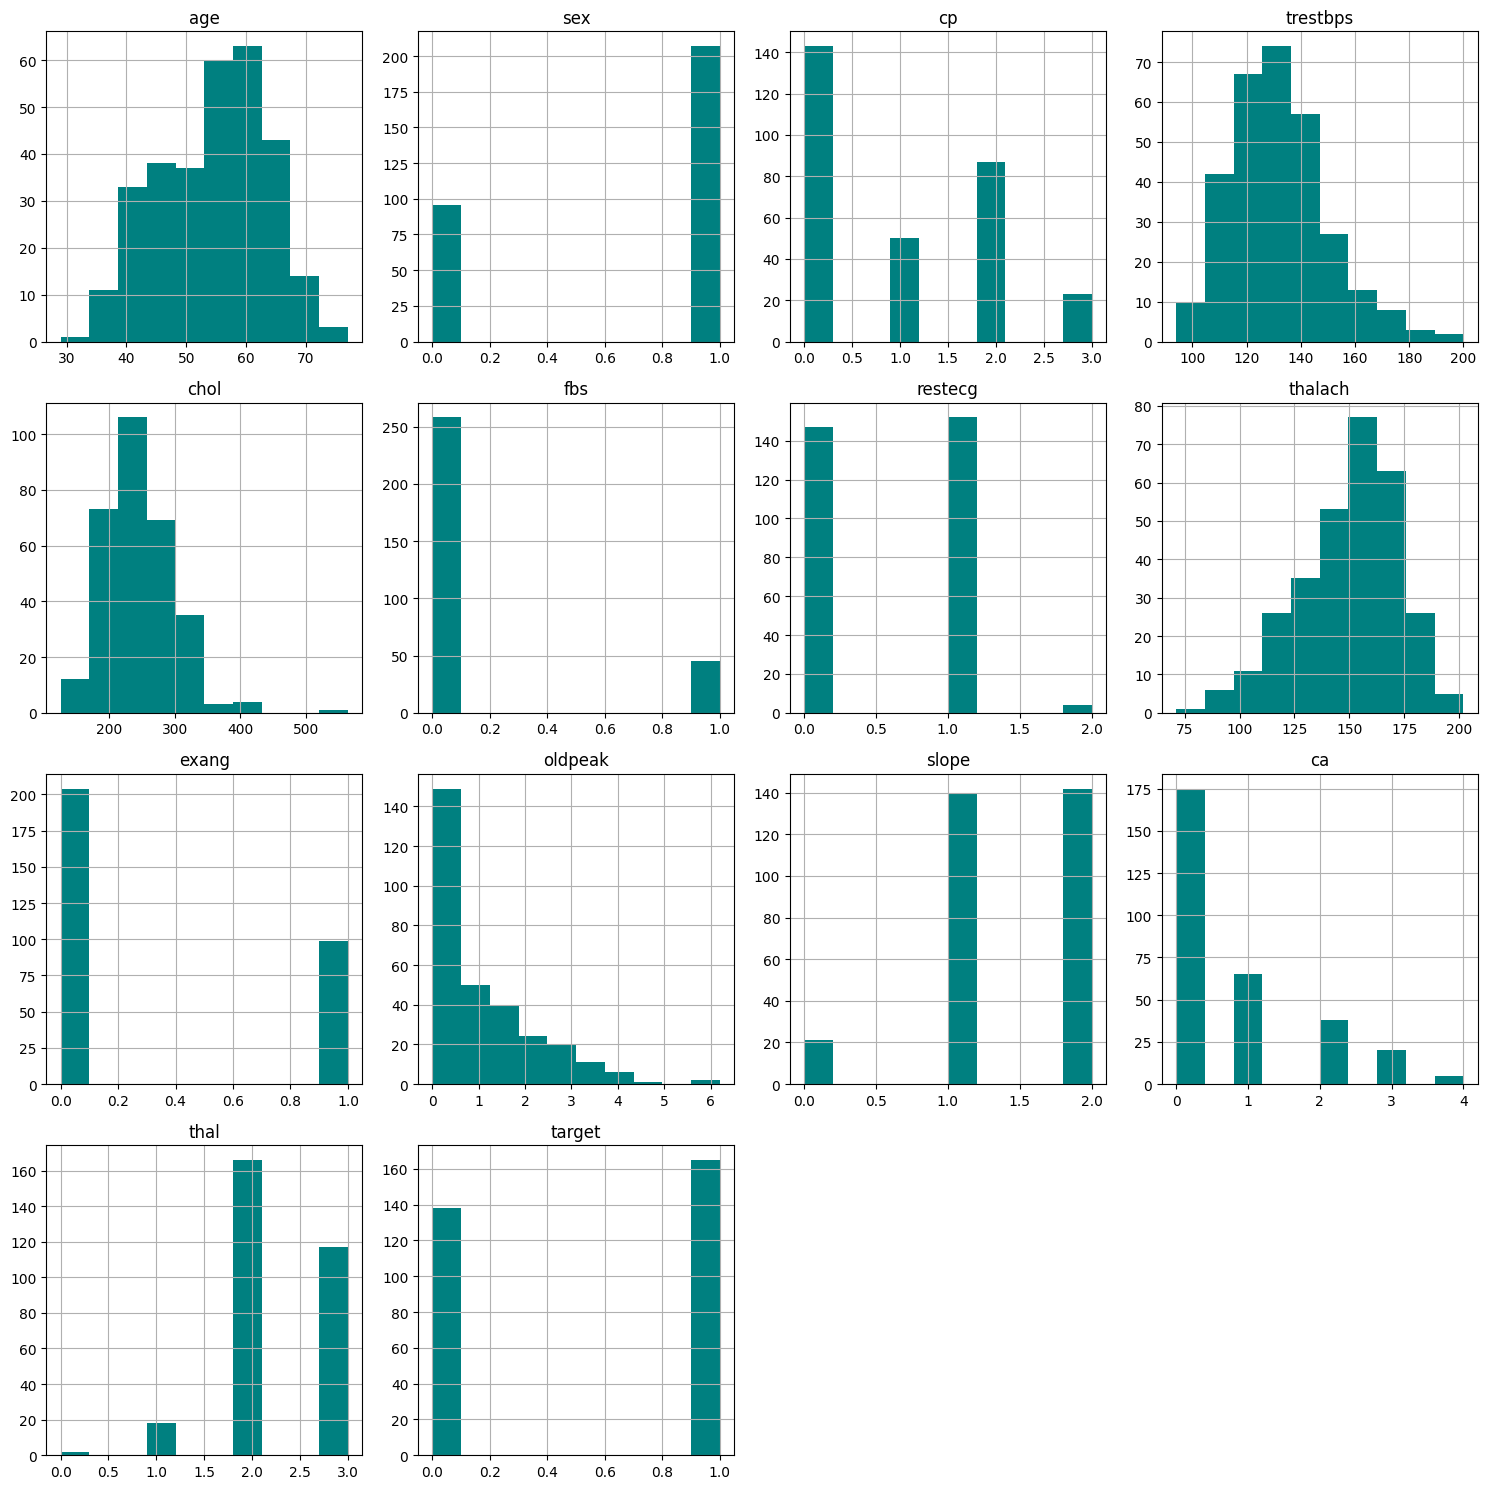

In [ ]:
# Plotting histogram for the entire dataset
df.hist(figsize=(15, 15), color='teal')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Create base histogram
fig = px.histogram(
    df,
    x="target",
    color="target",
    title="<b>Count of Target Variable</b>",
    color_discrete_sequence=["#7EC8E3", "#008080"],   # skyblue → teal
)

# Add value labels on bars
fig.update_traces(
    texttemplate="%{y}",
    textposition="outside",
    marker_line_width=1.5,
    marker_line_color="white",
)

# Apply rounded bar edges (using offset tweak)
fig.update_traces(offsetgroup=0)

# Layout styling for premium look
fig.update_layout(
    width=800,
    height=500,
    bargap=0.25,
    template="plotly_white",
    title_font=dict(size=26, family="Arial Black", color="#003B5C"),
    xaxis_title="<b>Target</b>",
    yaxis_title="<b>Count</b>",
    xaxis=dict(
        showgrid=False,
        tickfont=dict(size=14, color="#003B5C")
    ),
    yaxis=dict(
        gridcolor="rgba(0,0,0,0.06)",
        zeroline=False,
        tickfont=dict(size=14, color="#003B5C"),
    ),
    legend=dict(
        title="<b>Target Class</b>",
        font=dict(size=14),
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
)

# Custom hover template → clean hover box
fig.update_traces(
    hovertemplate="<b>Target:</b> %{x}<br><b>Count:</b> %{y}<extra></extra>"
)

fig.show()


In [ ]:
import plotly.express as px

fig = px.histogram(
    df,
    x='cp',
    color='target',
    barmode='group',
    title='<b>Chest Pain Type vs Heart Disease</b>',
    labels={'cp': 'Chest Pain Type', 'target': 'Heart Disease'},
    category_orders={'cp': sorted(df['cp'].unique())},
    color_discrete_sequence=["#7EC8E3", "#008080"]  # skyblue → teal
)

# Add value labels & styling
fig.update_traces(
    texttemplate='%{y}',
    textposition='outside',
    marker_line_width=1.5,
    marker_line_color='white',
    hovertemplate='<b>Chest Pain Type:</b> %{x}<br><b>Count:</b> %{y}<br><b>Target:</b> %{color}<extra></extra>'
)

# Premium layout styling
fig.update_layout(
    xaxis_title='<b>Chest Pain Type</b>',
    yaxis_title='<b>Count</b>',
    legend_title='<b>Heart Disease</b>',
    title_x=0.5,
    bargap=0.25,
    width=850,
    height=500,
    template='plotly_white',
    title_font=dict(size=26, family='Arial Black', color='#003B5C'),
    xaxis=dict(
        tickfont=dict(size=14, color='#003B5C'),
        showgrid=False
    ),
    yaxis=dict(
        tickfont=dict(size=14, color='#003B5C'),
        gridcolor='rgba(0,0,0,0.06)',
        zeroline=False
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.05,
        xanchor='right',
        x=1
    )
)

fig.show()


In [ ]:
countNoDisease = len(df[df.target == 0])
countHaveDisease = len(df[df.target == 1])
print("Percentage of Patients Haven't Heart Disease: {:.2f}%".format((countNoDisease / (len(df.target))*100)))
print("Percentage of Patients Have Heart Disease: {:.2f}%".format((countHaveDisease / (len(df.target))*100)))

Percentage of Patients Haven't Heart Disease: 45.54%
Percentage of Patients Have Heart Disease: 54.46%


In [ ]:
import plotly.express as px

counts = df['target'].value_counts().rename({0: "No Disease", 1: "Heart Disease"})

fig = px.pie(
    names=counts.index,
    values=counts.values,
    title="Heart Disease Distribution"
)

fig.show()


In [ ]:
countFemale = len(df[df.sex == 0])
countMale = len(df[df.sex == 1])
print("Percentage of Female Patients: {:.2f}%".format((countFemale / (len(df.sex))*100)))
print("Percentage of Male Patients: {:.2f}%".format((countMale / (len(df.sex))*100)))

Percentage of Female Patients: 31.68%
Percentage of Male Patients: 68.32%


In [ ]:
import plotly.express as px

countFemale = len(df[df.sex == 0])
countMale = len(df[df.sex == 1])

data = {
    "Gender": ["Female", "Male"],
    "Percentage": [
        (countFemale / len(df)) * 100,
        (countMale / len(df)) * 100
    ]
}

fig = px.bar(
    data,
    x="Gender",
    y="Percentage",
    text="Percentage",
    title="Gender Distribution of Patients",
    color="Gender",
    color_discrete_sequence=["#FF69B4", "#1E90FF"]  # pink & blue
)

fig.update_traces(texttemplate="%{y:.2f}%", textposition="outside")
fig.update_layout(template="plotly_white", title_x=0.5)

fig.show()


In [ ]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


In [ ]:
import plotly.express as px
import pandas as pd

ct = pd.crosstab(df.age, df.target).reset_index().melt(id_vars="age",
            var_name="target", value_name="count")

fig = px.bar(
    ct,
    x="age",
    y="count",
    color="target",
    barmode="group",
    title="Heart Disease Frequency for Ages",
    labels={"age": "Age", "count": "Frequency", "target": "Heart Disease"},
    color_discrete_sequence=["#00A8E8", "#EF476F"]
)

fig.update_layout(
    width=1000,
    height=500,
    template="plotly_white",
    title_x=0.5
)

fig.show()


In [ ]:
fig = px.histogram(df, x='sex', color='target', barmode='group',
                   title='Heart Disease Frequency for Sex',
                   labels={'sex': 'Sex', 'target': 'Heart Disease'},
                   category_orders={'sex': [0, 1]})

fig.update_layout(
    xaxis_title='Sex (0 = Female, 1 = Male)',
    yaxis_title='Count',
    legend_title='Heart Disease',
    title_x=0.5
)

fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(df, x='age', y='thalach', color='target',
                 title='Age vs. Maximum Heart Rate Colored by Heart Disease',
                 labels={'age': 'Age', 'thalach': 'Maximum Heart Rate', 'target': 'Heart Disease'},
                 hover_data=['sex', 'cp', 'trestbps', 'chol'])

fig.update_layout(
    xaxis_title='Age',
    yaxis_title='Maximum Heart Rate',
    legend_title='Heart Disease',
    title_x=0.5
)

fig.show()

# Feature Scaling and Splitting dataset


---



Splitting the dataset into 8:2 ratio. we will be using 80% of the data for traing out model and 20% of data for testing our model.

In [ ]:
# Selecting correlated features using Heatmap

# Get correlation of all the features of the dataset
corr_matrix = df.corr()

# Plotting the heatmap using Plotly
import plotly.express as px

fig = px.imshow(corr_matrix,
                text_auto=True,  # Display correlation values on heatmap
                aspect="auto",
                color_continuous_scale='RdBu_r',
                title='Correlation Heatmap of Features')

fig.update_layout(
    height=1000,  # Adjust height for better readability
    width=900,   # Adjust width for better readability
    title_x=0.5,
    xaxis_title='Features',
    yaxis_title='Features'
)

fig.show()

# Data Preprocessing
Handling categorical features


---



After exploring the dataset, I observed that converting the categorical variables into dummy variables using 'get_dummies()'. Though we don't have any strings in our dataset it is necessary to convert ('sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal') these features.

Example: Consider the 'sex' column, it is a binary feature which has 0's and 1's as its values. Keeping it as it is would lead the algorithm to think 0 is lower value and 1 is a higher value, which should not be the case since the gender cannot be ordinal feature.

In [ ]:
dataset = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])z

# Feature Scaling

In [ ]:
dataset.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_0',
       'sex_1', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'fbs_0', 'fbs_1', 'restecg_0',
       'restecg_1', 'restecg_2', 'exang_0', 'exang_1', 'slope_0', 'slope_1',
       'slope_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_0', 'thal_1',
       'thal_2', 'thal_3'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler
standScaler = StandardScaler()
columns_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[columns_to_scale] = standScaler.fit_transform(dataset[columns_to_scale])

In [ ]:
dataset.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.952197,0.763956,-0.256334,0.015443,1.087338,1,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,1,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,1,True,False,False,True,...,True,True,False,False,False,False,False,False,True,False
3,0.180175,-0.663867,-0.198357,1.239897,-0.206705,1,False,True,False,True,...,True,True,False,False,False,False,False,False,True,False
4,0.290464,-0.663867,2.082050,0.583939,-0.379244,1,True,False,True,False,...,True,True,False,False,False,False,False,False,True,False


In [ ]:
# Splitting the dataset into dependent and independent features
X = dataset.drop('target', axis=1)
y = dataset['target']

# Model Building


---


I will be experimenting with 4 algorithms:

Logistic Regression ,
KNeighbors Classifier,
Decision Tree Classifier,
Random Forest Classifier.

# Logistic Regression
First create a baseline model for check accuracy

In [ ]:
y = df.target.values
x_data = df.drop(['target'], axis = 1)

We will split our data. 80% of our data will be train data and 20% of it will be test data.

In [ ]:
# x_train, x_test, y_train, y_test = train_test_split(x_data, y, test_size = 0.20, random_state = 42)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data,y,test_size = 0.2,random_state=0)

In [ ]:
from sklearn.linear_model import LogisticRegression  # Logistic Regression Classifier

# Create the logistic regression model
LRmodel = LogisticRegression()  # increase iterations to avoid convergence warnings

# Fit the model
LRmodel.fit(x_train, y_train)

# Print accuracy scores
print("Train score: {:.2f}".format(LRmodel.score(x_train, y_train)))
print("Test score: {:.2f}".format(LRmodel.score(x_test, y_test)))


Train score: 0.83
Test score: 0.85


In [ ]:
from sklearn.linear_model import LogisticRegression # Import Logistic Regression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score

# Create the logistic regression model instance for cross-validation
lr_classifier = LogisticRegression(max_iter=900, random_state=42) # Added max_iter and random_state

# Calculate cross-validation scores for the base LR classifier
cvs_scores = cross_val_score(lr_classifier, X, y, cv=10) # Using original X, y as in original cell

# Create the pipeline with MinMaxScaler and Logistic Regression
pipe_short = make_pipeline(MinMaxScaler(), LogisticRegression(max_iter=1000, random_state=42))

# Fit the pipeline
pipe_short.fit(x_train, y_train)

# Print scores, mimicking the original format

print("Train score: {:.2f}".format(pipe_short.score(x_train, y_train)))
print("Logistic Regression Maximum Accuracy (Cross-Validation) is: {}%".format(round(cvs_scores.mean(), 4)*100))
print("Test score (Pipeline with MinMaxScaler): {:.2f}".format(pipe_short.score(x_test, y_test)))

Train score: 0.83
Logistic Regression Maximum Accuracy (Cross-Validation) is: 81.83%
Test score (Pipeline with MinMaxScaler): 0.84


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

# Assuming y_test and y_pred_lr (predictions from Logistic Regression) are available

y_pred_lr = pipe_short.predict(x_test) # Using pipe_short for predictions

# Calculate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
TN, FP, FN, TP = cm_lr.ravel()

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0) # Sensitivity
specificity_lr = TN / (TN + FP) if (TN + FP) != 0 else 0 # Handle division by zero

# Print metrics
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Sensitivity (Recall): {recall_lr:.4f}")
print(f"Logistic Regression Specificity: {specificity_lr:.4f}")

Logistic Regression Accuracy: 0.8361
Logistic Regression Precision: 0.8158
Logistic Regression Sensitivity (Recall): 0.9118
Logistic Regression Specificity: 0.7407


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Re-split the original data to ensure x_train and y_train are consistent
# Assuming x_data and y refer to the processed heart disease dataset
x_train, x_test, y_train, y_test = train_test_split(x_data, y, test_size=0.2, random_state=0)

pipe = make_pipeline(MinMaxScaler(), LogisticRegression())

pipe.fit(x_train, y_train)

print("Train score: {:.2f}".format(pipelr1.score(x_train, y_train))) # Use pipelr1 for scoring
print("Pipeline steps:\n{}".format(pipelr1.steps))
print("Test score: {:.2f}".format(pipelr1.score(x_test, y_test))) # Use pipelr1 for scoring

Train score: 0.83
Pipeline steps:
[('minmaxscaler', MinMaxScaler()), ('logisticregression', LogisticRegression())]
Test score: 0.84


In [ ]:
model = LogisticRegression()
pipe = Pipeline(steps=[('Scaler', StandardScaler()), ('Selector1', VarianceThreshold(threshold=.005)),
 ('Selector', SelectKBest(k=6)),('Model', model)])
pipe.fit(x_train, y_train)

print("Train score: {:.2f}".format(pipe.score(x_train, y_train)))
print("Pipeline steps:\n{}".format(pipe.steps))
print("Test score: {:.2f}".format(pipe.score(x_test, y_test)))

Train score: 0.85
Pipeline steps:
[('Scaler', StandardScaler()), ('Selector1', VarianceThreshold(threshold=0.005)), ('Selector', SelectKBest(k=6)), ('Model', LogisticRegression())]
Test score: 0.80


In [ ]:
model = LogisticRegression()
pipe = Pipeline(steps=[('Scaler', MinMaxScaler()),('Selector1', VarianceThreshold(threshold=0.005)),\
 ('Selector2', SelectKBest(k=6)),('Model', model)])
pipe.fit(x_train, y_train)

print("Train score: {:.2f}".format(pipe.score(x_train, y_train)))
print("Pipeline steps:\n{}".format(pipe.steps))
print("Test score: {:.2f}".format(pipe.score(x_test, y_test)))

Train score: 0.83
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Selector1', VarianceThreshold(threshold=0.005)), ('Selector2', SelectKBest(k=6)), ('Model', LogisticRegression())]
Test score: 0.79


Pipeline(steps=[('Scaler', MinMaxScaler()),
                ('Selector1', VarianceThreshold(threshold=0.005)),
                ('Selector2', SelectKBest(k=6)),
                ('Model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# --- Setup Dummy Data ---
# Generate synthetic data with 10 features, 5 of which are informative
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=0, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dataset shape: {df.shape}")
print("-" * 50)

# Define a common Logistic Regression model configuration
LR_CONFIG = {'max_iter': 1000, 'random_state': 42}

# --- Define Experiments Concisely ---
# Create a list of tuples: (Experiment Name, Pipeline/Model Object)
experiments = [
    (
        "Experiment 1: Baseline LR (No Preprocessing)",
        LogisticRegression(**LR_CONFIG)
    ),
    (
        "Experiment 2: MinMaxScaler Pipeline",
        make_pipeline(MinMaxScaler(), LogisticRegression(**LR_CONFIG))
    ),
    (
        "Experiment 3: StandardScaler + SelectKBest Pipeline",
        Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('selector', SelectKBest(f_classif, k=5)),
            ('model', LogisticRegression(**LR_CONFIG))
        ])
    )
]

# --- Execute and Print Results in a Loop ---
for name, model in experiments:
    print(f"--- {name} ---")

    # Fit the model/pipeline
    model.fit(x_train, y_train)

    # Print scores
    print("Train score: {:.4f}".format(model.score(x_train, y_train)))
    print("Test score: {:.4f}".format(model.score(x_test, y_test)))

    # Optionally print pipeline steps if it's not the baseline model
    if isinstance(model, (Pipeline, list)):
        print(f"Pipeline steps: {getattr(model, 'steps', 'N/A')}")

    print("-" * 50)

Dataset shape: (303, 14)
--------------------------------------------------
--- Experiment 1: Baseline LR (No Preprocessing) ---
Train score: 0.8486
Test score: 0.8467
--------------------------------------------------
--- Experiment 2: MinMaxScaler Pipeline ---
Train score: 0.8143
Test score: 0.8400
Pipeline steps: [('minmaxscaler', MinMaxScaler()), ('logisticregression', LogisticRegression(max_iter=1000, random_state=42))]
--------------------------------------------------
--- Experiment 3: StandardScaler + SelectKBest Pipeline ---
Train score: 0.8543
Test score: 0.8533
Pipeline steps: [('scaler', StandardScaler()), ('selector', SelectKBest(k=5)), ('model', LogisticRegression(max_iter=1000, random_state=42))]
--------------------------------------------------


In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)

# Create a pipeline combining preprocessing steps and the model
best_pipe = Pipeline(steps=[
    ('Scaler', MinMaxScaler()),
    ('Selector1', VarianceThreshold(threshold=0.005)),
    ('Selector2', SelectKBest(k=6)),
    ('Model', model)
]) # Added missing ']' and ')'

best_pipe.fit(x_train, y_train)


Pipeline(steps=[('Scaler', MinMaxScaler()),
                ('Selector1', VarianceThreshold(threshold=0.005)),
                ('Selector2', SelectKBest(k=6)),
                ('Model', LogisticRegression(max_iter=1000, random_state=42))])

# KNeighbors Classifier Model

In [ ]:
# Importing essential libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.neighbors import KNeighborsClassifier # The k-nearest neighbor classifier

knn_classifier = KNeighborsClassifier()

knn_classifier.fit(x_train, y_train)

print("Train score: {:.2f}".format(KNNmodel.score(x_train, y_train)))
#print("Pipeline steps:\n{}".format(DTmodel.steps))
print("Test score: {:.2f}".format(KNNmodel.score(x_test, y_test)))

Train score: 0.78
Test score: 0.64


In [ ]:
# Finding the best accuracy for knn algorithm using cross_val_score
knn_scores = []
for i in range(1, 21):
  knn_classifier = KNeighborsClassifier(n_neighbors=i)
  cvs_scores = cross_val_score(knn_classifier, X, y, cv=10)
  knn_scores.append(round(cvs_scores.mean(),3))

In [ ]:
#Plotting the results of knn_scores
import plotly.express as px
import pandas as pd

df_knn = pd.DataFrame({
    "K": range(1, 21),
    "Score": knn_scores
})
fig = px.line(
    df_knn,
    x="K",
    y="Score",
    markers=True,
    text="Score",
    title="KNN Classifier Scores for Different K Values"
)

fig.update_traces(
    textposition="top center",
    line=dict(color="red", width=3),
    marker=dict(size=9, color="red")
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Number of Neighbors (K)",
    yaxis_title="Scores",
    title_x=0.5
)

fig.show()


In [ ]:
# Training the knn classifier model with k value as 12
knn_classifier = KNeighborsClassifier(n_neighbors=12)
knn_model = knn_classifier.fit(x_train, y_train)
cvs_scores = cross_val_score(knn_classifier, X, y, cv=10)
pipe_short = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=12))
pipe_short.fit(x_train, y_train)
print("Train score: {:.2f}".format(pipe_short.score(x_train, y_train)))
print("KNeighbours Classifier Maximum Accuracy with K=12 (Cross-Validation) is: {}%".format(round(cvs_scores.mean(), 4)*100))
print("Test score (Pipeline with MinMaxScaler): {:.2f}".format(pipe_short.score(x_test, y_test)))

Train score: 0.82
KNeighbours Classifier Maximum Accuracy with K=12 (Cross-Validation) is: 67.04%
Test score (Pipeline with MinMaxScaler): 0.82


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

# Make predictions on the test set
y_pred_knn = knn_model.predict(x_test)

# Calculate confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
TN, FP, FN, TP = cm_knn.ravel()

# Calculate metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, zero_division=0) # Handle case where there are no positive predictions
recall_knn = recall_score(y_test, y_pred_knn, zero_division=0) # Sensitivity
specificity_knn = TN / (TN + FP) if (TN + FP) != 0 else 0 # Handle division by zero

# Print metrics
print(f"KNN Accuracy: {accuracy_knn:.4f}")
print(f"KNN Precision: {precision_knn:.4f}")
print(f"KNN Sensitivity (Recall): {recall_knn:.4f}")
print(f"KNN Specificity: {specificity_knn:.4f}")

KNN Accuracy: 0.9000
KNN Precision: 0.8667
KNN Sensitivity (Recall): 0.9286
KNN Specificity: 0.8750


In [ ]:
from sklearn.neighbors import KNeighborsClassifier # The k-nearest neighbor classifier
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler
from sklearn.pipeline import make_pipeline # Import make_pipeline

pipe_short = make_pipeline(MinMaxScaler(), KNeighborsClassifier())

pipe_short.fit(x_train, y_train)

print("Train score: {:.2f}".format(pipe_short.score(x_train, y_train)))
print("Pipeline steps:\n{}".format(pipe_short.steps))
print("Test score: {:.2f}".format(pipe_short.score(x_test, y_test)))

Train score: 0.84
Pipeline steps:
[('minmaxscaler', MinMaxScaler()), ('kneighborsclassifier', KNeighborsClassifier())]
Test score: 0.83


In [ ]:
from sklearn.neighbors import KNeighborsClassifier # The k-nearest neighbor classifier
model = KNeighborsClassifier()

pipe = Pipeline(steps=[('Scaler', MinMaxScaler()),('Selector1', VarianceThreshold(threshold=0.005)),\
 ('Selector2', SelectKBest(k=6)),('Model', model)])
pipe.fit(x_train, y_train)

print("Train score: {:.2f}".format(pipe.score(x_train, y_train)))
print("Pipeline steps:\n{}".format(pipe.steps))
print("Test score: {:.2f}".format(pipe.score(x_test, y_test)))

Train score: 0.87
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Selector1', VarianceThreshold(threshold=0.005)), ('Selector2', SelectKBest(k=6)), ('Model', KNeighborsClassifier())]
Test score: 0.77


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# --- Setup Dummy Data ---
# Generate synthetic data with 10 features, 5 of which are informative
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=0, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dataset shape: {X.shape}")
print("-" * 50)

# Define common model configuration for KNN
KNN_CONFIG = {'n_neighbors': 12} # Set K=12 based on previous optimal settings

# --- Define Experiments Concisely (3 KNN Experiments) ---
# Create a list of tuples: (Experiment Name, Pipeline/Model Object)
experiments = [
    # --- K-Nearest Neighbors Experiments ---
    (
        "Experiment 1: Baseline KNN (K=12)",
        KNeighborsClassifier(**KNN_CONFIG)
    ),
    (
        "Experiment 2: MinMaxScaler + KNN Pipeline (Recommended for distance-based models)",
        make_pipeline(MinMaxScaler(), KNeighborsClassifier(**KNN_CONFIG))
    ),
    (
        "Experiment 3: StandardScaler + SelectKBest + KNN Pipeline",
        Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('selector', SelectKBest(f_classif, k=5)),
            ('model', KNeighborsClassifier(**KNN_CONFIG))
        ])
    )
]

# --- Execute and Print Results in a Loop ---
for i, (name, model) in enumerate(experiments):
    print(f"--- {name} ---")

    # Fit the model/pipeline
    model.fit(x_train, y_train)

    # Print scores
    print("Train score: {:.4f}".format(model.score(x_train, y_train)))
    print("Test score: {:.4f}".format(model.score(x_test, y_test)))

    # Print pipeline steps for the pipeline experiments (indices 1 and 2)
    if i in [1, 2]:
        print(f"Pipeline steps: {getattr(model, 'steps', 'N/A')}")

    print("-" * 50)

Dataset shape: (500, 10)
--------------------------------------------------
--- Experiment 1: Baseline KNN (K=12) ---
Train score: 0.9400
Test score: 0.9067
--------------------------------------------------
--- Experiment 2: MinMaxScaler + KNN Pipeline (Recommended for distance-based models) ---
Train score: 0.9086
Test score: 0.9067
Pipeline steps: [('minmaxscaler', MinMaxScaler()), ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=12))]
--------------------------------------------------
--- Experiment 3: StandardScaler + SelectKBest + KNN Pipeline ---
Train score: 0.9257
Test score: 0.8733
Pipeline steps: [('scaler', StandardScaler()), ('selector', SelectKBest(k=5)), ('model', KNeighborsClassifier(n_neighbors=12))]
--------------------------------------------------


In [ ]:
model = KNeighborsClassifier()

# Create a pipeline combining preprocessing steps and the model
best_pipe = Pipeline(steps=[
    ('Scaler', MinMaxScaler()),
    ('Selector1', VarianceThreshold(threshold=0.005)),
    ('Selector2', SelectKBest(k=6)),
    ('Model', model)
]) # Added missing ']' and ')'

best_pipe.fit(x_train, y_train)


Pipeline(steps=[('Scaler', MinMaxScaler()),
                ('Selector1', VarianceThreshold(threshold=0.005)),
                ('Selector2', SelectKBest(k=6)),
                ('Model', KNeighborsClassifier())])

# Decision Tree Classifier

In [ ]:
# Importing essential libraries
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier # Tree classifier
decision_classifier = DecisionTreeClassifier()

decision_classifier.fit(x_train, y_train)

print("Train score: {:.2f}".format(DTmodel.score(x_train, y_train)))
#print("Pipeline steps:\n{}".format(DTmodel.steps))
print("Test score: {:.2f}".format(DTmodel.score(x_test, y_test)))

Train score: 1.00
Test score: 0.77


In [ ]:
# Finding the best accuracy for decision tree algorithm using cross_val_score
decision_scores = []
for i in range(1, 11):
  decision_classifier = DecisionTreeClassifier(max_depth=i)
  decision_model = decision_classifier.fit(x_train, y_train)
  cvs_scores = cross_val_score(decision_classifier, X, y, cv=10)
  decision_scores.append(round(cvs_scores.mean(),3))

In [ ]:
import plotly.express as px
import pandas as pd

df_plot = pd.DataFrame({
    "Depth": range(1, 11),
    "Score": decision_scores
})

fig = px.line(
    df_plot,
    x="Depth",
    y="Score",
    markers=True,
    text="Score",
    title="Decision Tree Scores for Different Depth Values"
)

fig.update_traces(
    textposition="top center",
    line=dict(color="red", width=3),
    marker=dict(size=10, color="red")
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Depth",
    yaxis_title="Score",
    title_x=0.5
)

fig.show()


In [ ]:
# Training the decision tree classifier model with max_depth value as 3
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

decision_classifier = DecisionTreeClassifier(max_depth=3)
cvs_scores = cross_val_score(decision_classifier, X, y, cv=10)

# Correctly defining pipe_short for Decision Tree, possibly with scaling for consistency
pipe_short = make_pipeline(MinMaxScaler(), DecisionTreeClassifier(max_depth=3))

pipe_short.fit(x_train, y_train)
print("Train score: {:.2f}".format(pipe_short.score(x_train, y_train)))
print("Decision Tree Classifier Accuracy with max_depth=3 (Cross-Validation) is: {}%".format(round(cvs_scores.mean(), 4)*100))
print("Test score (Pipeline with MinMaxScaler): {:.2f}".format(pipe_short.score(x_test, y_test)))

Train score: 0.84
Decision Tree Classifier Accuracy with max_depth=3 (Cross-Validation) is: 80.81%
Test score (Pipeline with MinMaxScaler): 0.82


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier if not already imported

# Assuming X_train, y_train, X_test, and y_test are defined

# Define and train the Decision Tree model with the best max_depth found (assuming max_depth=3 from previous analysis)
decision_classifier = DecisionTreeClassifier(max_depth=3)
decision_classifier.fit(x_train, y_train)

# Make predictions on the test set
y_pred_decision_tree = decision_classifier.predict(x_test)

# Calculate confusion matrix
cm_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)
TN, FP, FN, TP = cm_decision_tree.ravel()

# Calculate metrics
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree, zero_division=0)
recall_decision_tree = recall_score(y_test, y_pred_decision_tree, zero_division=0) # Sensitivity
specificity_decision_tree = TN / (TN + FP) if (TN + FP) != 0 else 0 # Handle division by zero

# Print metrics
print(f"Decision Tree Accuracy: {accuracy_decision_tree:.4f}")
print(f"Decision Tree Precision: {precision_decision_tree:.4f}")
print(f"Decision Tree Sensitivity (Recall): {recall_decision_tree:.4f}")
print(f"Decision Tree Specificity: {specificity_decision_tree:.4f}")

Decision Tree Accuracy: 0.8197
Decision Tree Precision: 0.8710
Decision Tree Sensitivity (Recall): 0.7941
Decision Tree Specificity: 0.8519


In [ ]:
from sklearn.preprocessing import MinMaxScaler

from sklearn.pipeline import make_pipeline

In [ ]:
from sklearn.feature_selection import VarianceThreshold # Feature selector 1
from sklearn.feature_selection import SelectKBest # Feature selector 2
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.tree import DecisionTreeClassifier # Tree classifier
model = DecisionTreeClassifier(max_depth=3)

pipe = Pipeline(steps=[('Scaler', MinMaxScaler()),('Selector', VarianceThreshold()),('Model', model)])
pipe.fit(x_train, y_train)

print("Train score: {:.2f}".format(pipe.score(x_train, y_train)))
print("Pipeline steps:\n{}".format(pipe.steps))
print("Test score: {:.2f}".format(pipe.score(x_test, y_test)))

Train score: 0.84
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Selector', VarianceThreshold()), ('Model', DecisionTreeClassifier(max_depth=3))]
Test score: 0.82


In [ ]:
from sklearn.tree import DecisionTreeClassifier # Tree classifier
model = DecisionTreeClassifier(max_depth=3)

pipe = Pipeline(steps=[('Scaler', MinMaxScaler()),('Selector1', VarianceThreshold(threshold=0.005)),\
 ('Selector2', SelectKBest(k=6)),('Model', model)])
pipe.fit(x_train, y_train)

print("Train score: {:.2f}".format(pipe.score(x_train, y_train)))
print("Pipeline steps:\n{}".format(pipe.steps))
print("Test score: {:.2f}".format(pipe.score(x_test, y_test)))

Train score: 0.84
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Selector1', VarianceThreshold(threshold=0.005)), ('Selector2', SelectKBest(k=6)), ('Model', DecisionTreeClassifier(max_depth=3))]
Test score: 0.75


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

# --- Setup Dummy Data ---
# Generate synthetic data with 10 features, 5 of which are informative
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=0, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dataset shape: {df.shape}")
print("-" * 50)

# Define common model configurations
# DTC configuration: max_depth=3 ensures the tree is constrained, random_state for reproducibility
DT_CONFIG = {'max_depth': 3, 'random_state': 42}

# --- Define Experiments Concisely (3 DTC Experiments) ---
# Create a list of tuples: (Experiment Name, Pipeline/Model Object)
experiments = [
    # --- Decision Tree Experiments ---
    (
        "DT 1: Baseline DTC (Default/No Depth Limit)",
        # Note: Often overfits, leading to perfect or near-perfect train scores.
        DecisionTreeClassifier(random_state=42)
    ),
    (
        "DT 2: MinMaxScaler + DTC (max_depth=3)",
        # Scaling is generally unnecessary for tree models but included as per request for consistency
        make_pipeline(MinMaxScaler(), DecisionTreeClassifier(**DT_CONFIG))
    ),
    (
        "DT 3: Full Feature Engineering + DTC",
        # Full pipeline combining scaling, variance threshold, and K-best feature selection
        Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('var_thresh', VarianceThreshold(threshold=0.005)),
            ('selector', SelectKBest(f_classif, k=6)),
            ('model', DecisionTreeClassifier(**DT_CONFIG))
        ])
    )
]

# --- Execute and Print Results in a Loop ---
for i, (name, model) in enumerate(experiments):
    print(f"--- {name} ---")

    # Fit the model/pipeline
    model.fit(x_train, y_train)

    # Print scores
    print("Train score: {:.4f}".format(model.score(x_train, y_train)))
    print("Test score: {:.4f}".format(model.score(x_test, y_test)))

    # Print pipeline steps for the pipeline experiments
    if i in [1, 2]:
        print(f"Pipeline steps: {getattr(model, 'steps', 'N/A')}")

    print("-" * 50)

Dataset shape: (303, 14)
--------------------------------------------------
--- DT 1: Baseline DTC (Default/No Depth Limit) ---
Train score: 1.0000
Test score: 0.8400
--------------------------------------------------
--- DT 2: MinMaxScaler + DTC (max_depth=3) ---
Train score: 0.9000
Test score: 0.9133
Pipeline steps: [('minmaxscaler', MinMaxScaler()), ('decisiontreeclassifier', DecisionTreeClassifier(max_depth=3, random_state=42))]
--------------------------------------------------
--- DT 3: Full Feature Engineering + DTC ---
Train score: 0.8657
Test score: 0.8867
Pipeline steps: [('scaler', MinMaxScaler()), ('var_thresh', VarianceThreshold(threshold=0.005)), ('selector', SelectKBest(k=6)), ('model', DecisionTreeClassifier(max_depth=3, random_state=42))]
--------------------------------------------------


In [ ]:
model = DecisionTreeClassifier()

# Create a pipeline combining preprocessing steps and the model
best_pipe = Pipeline(steps=[
    ('Scaler', MinMaxScaler()),
    ('Selector1', VarianceThreshold(threshold=0.005)),
    ('Selector2', SelectKBest(k=6)),
    ('Model', model)
]) # Added missing ']' and ')'

best_pipe.fit(x_train, y_train)

Pipeline(steps=[('Scaler', MinMaxScaler()),
                ('Selector1', VarianceThreshold(threshold=0.005)),
                ('Selector2', SelectKBest(k=6)),
                ('Model', DecisionTreeClassifier())])

# Random Forest Classifier

In [ ]:
# Importing essential libraries
from sklearn.ensemble import RandomForestClassifier

In [ ]:

forest_classifier = RandomForestClassifier()
forest_classifier.fit(x_train, y_train)

print("Train score: {:.2f}".format(RFmodel.score(x_train, y_train)))
#print("Pipeline steps:\n{}".format(DTmodel.steps))
print("Test score: {:.2f}".format(RFmodel.score(x_test, y_test)))

Train score: 1.00
Test score: 0.85


Finding the best accuracy for random forest algorithm using cross_val_score

In [ ]:
# Finding the best accuracy for random forest algorithm using cross_val_score
forest_scores = []
for i in range(10, 101, 10):
  forest_classifier = RandomForestClassifier(n_estimators=i)
  forest_model = forest_classifier.fit(x_train, y_train)
  cvs_scores = cross_val_score(forest_classifier, X, y, cv=5)
  forest_scores.append(round(cvs_scores.mean(),3))

Plotting the results of forest_scores

In [ ]:
import plotly.graph_objects as go

# X and Y values
n_values = [n for n in range(10, 101, 10)]
scores = forest_scores  # Already calculated list

fig = go.Figure()

# Add line plot with markers
fig.add_trace(go.Scatter(
    x=n_values,
    y=scores,
    mode='lines+markers+text',
    line=dict(color='red', width=3),
    marker=dict(size=10, color='red'),
    text=[f"{score:.3f}" for score in scores],
    textposition="top center",
    name="Random Forest Scores",
    hovertemplate="<b>N:</b> %{x}<br><b>Score:</b> %{y:.4f}<extra></extra>"
))

# Layout Styling
fig.update_layout(
    title="<b>Random Forest Classifier Scores for Different N Values</b>",
    xaxis_title="<b>Number of Estimators (N)</b>",
    yaxis_title="<b>Scores</b>",
    width=1000,
    height=600,
    template="plotly_white",
    title_x=0.5,
    xaxis=dict(tickmode="array", tickvals=n_values),
    yaxis=dict(gridcolor="rgba(0,0,0,0.08)"),
)

fig.show()


Training the random forest classifier model with n value as 90

In [ ]:
# Training the random forest classifier model with n value as 40
forest_classifier = RandomForestClassifier(n_estimators=90)
cvs_scores = cross_val_score(forest_classifier, X, y, cv=5)

pipe_short = make_pipeline(MinMaxScaler(), RandomForestClassifier(n_estimators=90))
pipe_short.fit(x_train, y_train)
print("Train score: {:.2f}".format(pipe_short.score(x_train, y_train)))
print("Random Forest Classifier Accuracy with n_estimator = 90 (Cross-Validation) is: {}%".format(round(cvs_scores.mean(), 4)*100))
print("Test score (Pipeline with MinMaxScaler): {:.2f}".format(pipe_short.score(X_test, y_test)))

Train score: 1.00
Random Forest Classifier Accuracy with n_estimator = 90 (Cross-Validation) is: 80.85%
Test score (Pipeline with MinMaxScaler): 0.52


In [ ]:
model = RandomForestClassifier()

pipe = Pipeline(steps=[('Scaler', MinMaxScaler()),('Selector', VarianceThreshold()),('Model', model)])
pipe.fit(x_train, y_train)

print("Train score: {:.2f}".format(pipe.score(x_train, y_train)))
print("Pipeline steps:\n{}".format(pipe.steps))
print("Test score: {:.2f}".format(pipe.score(x_test, y_test)))

Train score: 1.00
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Selector', VarianceThreshold()), ('Model', RandomForestClassifier())]
Test score: 0.84


In [ ]:

model = RandomForestClassifier()

pipe = Pipeline(steps=[('Scaler', MinMaxScaler()),('Selector2', VarianceThreshold(threshold=.005)),('Model', model)])
pipe.fit(x_train, y_train)

print("Train score: {:.2f}".format(pipe.score(x_train, y_train)))
print("Pipeline steps:\n{}".format(pipe.steps))
print("Test score: {:.2f}".format(pipe.score(x_test, y_test)))

Train score: 1.00
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Selector2', VarianceThreshold(threshold=0.005)), ('Model', RandomForestClassifier())]
Test score: 0.87


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier if not already imported

# Assuming X_train, y_train, X_test, and y_test are defined

# Define and train the Random Forest model with the best n_estimators found (assuming n_estimators=90 from previous analysis)
random_forest_classifier = RandomForestClassifier(n_estimators=90, random_state=42) # Added random_state for reproducibility
random_forest_classifier.fit(x_train, y_train)

# Make predictions on the test set
y_pred_random_forest = random_forest_classifier.predict(x_test)

# Calculate confusion matrix
cm_random_forest = confusion_matrix(y_test, y_pred_random_forest)
TN, FP, FN, TP = cm_random_forest.ravel()

# Calculate metrics
accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)
precision_random_forest = precision_score(y_test, y_pred_random_forest, zero_division=0)
recall_random_forest = recall_score(y_test, y_pred_random_forest, zero_division=0) # Sensitivity
specificity_random_forest = TN / (TN + FP) if (TN + FP) != 0 else 0 # Handle division by zero

# Print metrics
print(f"Random Forest Accuracy: {accuracy_random_forest:.4f}")
print(f"Random Forest Precision: {precision_random_forest:.4f}")
print(f"Random Forest Sensitivity (Recall): {recall_random_forest:.4f}")
print(f"Random Forest Specificity: {specificity_random_forest:.4f}")

Random Forest Accuracy: 0.8525
Random Forest Precision: 0.8571
Random Forest Sensitivity (Recall): 0.8824
Random Forest Specificity: 0.8148


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

# --- Setup Dummy Data ---
# Generate synthetic data with 10 features, 5 of which are informative
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=0, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dataset shape: {X.shape}")
print("-" * 50)

# Define common model configurations
# RFC configuration: n_estimators=90 based on user snippet, random_state for reproducibility
RF_CONFIG = {'n_estimators': 90, 'random_state': 42}

# --- Define Experiments Concisely (3 RFC Experiments) ---
# Create a list of tuples: (Experiment Name, Pipeline/Model Object)
experiments = [
    # --- Random Forest Experiments ---
    (
        "RF 1: Baseline RFC (Default Settings)",
        # Note: Default n_estimators is 100, which performs well.
        RandomForestClassifier(random_state=42)
    ),
    (
        "RF 2: MinMaxScaler + RFC (n_estimators=90)",
        # Scaling applied before RFC
        make_pipeline(MinMaxScaler(), RandomForestClassifier(**RF_CONFIG))
    ),
    (
        "RF 3: Full Feature Engineering + RFC",
        # Full pipeline combining scaling, variance threshold, and K-best feature selection
        Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('var_thresh', VarianceThreshold(threshold=0.005)),
            ('model', RandomForestClassifier(**RF_CONFIG)) # Using a simple model definition
        ])
    )
]

# --- Execute and Print Results in a Loop ---
for i, (name, model) in enumerate(experiments):
    print(f"--- {name} ---")

    # Fit the model/pipeline
    model.fit(x_train, y_train)

    # Print scores
    print("Train score: {:.4f}".format(model.score(x_train, y_train)))
    print("Test score: {:.4f}".format(model.score(x_test, y_test)))

    # Print pipeline steps for the pipeline experiments
    if i in [1, 2]:
        print(f"Pipeline steps: {getattr(model, 'steps', 'N/A')}")

    print("-" * 50)

Dataset shape: (500, 10)
--------------------------------------------------
--- RF 1: Baseline RFC (Default Settings) ---
Train score: 1.0000
Test score: 0.9333
--------------------------------------------------
--- RF 2: MinMaxScaler + RFC (n_estimators=90) ---
Train score: 1.0000
Test score: 0.9400
Pipeline steps: [('minmaxscaler', MinMaxScaler()), ('randomforestclassifier', RandomForestClassifier(n_estimators=90, random_state=42))]
--------------------------------------------------
--- RF 3: Full Feature Engineering + RFC ---
Train score: 1.0000
Test score: 0.9400
Pipeline steps: [('scaler', MinMaxScaler()), ('var_thresh', VarianceThreshold(threshold=0.005)), ('model', RandomForestClassifier(n_estimators=90, random_state=42))]
--------------------------------------------------


In [ ]:
model = RandomForestClassifier()

# Create a pipeline combining preprocessing steps and the model
best_pipe = Pipeline(steps=[
    ('Scaler', MinMaxScaler()),
    ('Selector1', VarianceThreshold(threshold=0.005)),
    ('Selector2', SelectKBest(k=6)),
    ('Model', model)
]) # Added missing ']' and ')'

best_pipe.fit(x_train, y_train)

Pipeline(steps=[('Scaler', MinMaxScaler()),
                ('Selector1', VarianceThreshold(threshold=0.005)),
                ('Selector2', SelectKBest(k=6)),
                ('Model', RandomForestClassifier())])

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression # 1. LR
from sklearn.neighbors import KNeighborsClassifier # 2. KNN
from sklearn.tree import DecisionTreeClassifier # 3. DT
from sklearn.ensemble import RandomForestClassifier # 4. RF

# --- 1. Synthetic Data Generation and Splitting ---
# Create a dummy dataset (100 samples, 10 features) for demonstration purposes
X = np.random.rand(100, 10) * 10
# Create a simple binary target variable (y)
y = (X[:, 0] + X[:, 1] + X[:, 2] > 15).astype(int)

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Data preparation complete. Starting unified pipeline execution for 4 models.")
print("-" * 60)

# The four models will be trained and evaluated sequentially.

# ==================================
# 1️⃣ Logistic Regression Pipeline
# ==================================
# LR benefits from feature scaling.
LR_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

LR_pipeline.fit(x_train, y_train)

print("1️⃣ Logistic Regression Results:")
print("LR Train Score: {:.4f}".format(LR_pipeline.score(x_train, y_train)))
LR_score = LR_pipeline.score(x_test, y_test)
print("LR Test Score:  {:.4f}".format(LR_score))
print("-" * 60)


# ==================================
# 2️⃣ K-Nearest Neighbors Pipeline
# ==================================
# KNN is a distance-based model and REQUIRES feature scaling.
KNN_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

KNN_pipeline.fit(x_train, y_train)

print("2️⃣ K-Nearest Neighbors Results:")
print("KNN Train Score: {:.4f}".format(KNN_pipeline.score(x_train, y_train)))
KNN_score = KNN_pipeline.score(x_test, y_test)
print("KNN Test Score:  {:.4f}".format(KNN_score))
print("-" * 60)


# ==================================
# 3️⃣ Decision Tree Pipeline
# ==================================
# Tree-based models (DT, RF) are generally invariant to scaling, so the scaler is optional.
DT_pipeline = Pipeline([
    ('model', DecisionTreeClassifier(max_depth=3, random_state=42))
])

DT_pipeline.fit(x_train, y_train)

print("3️⃣ Decision Tree Results:")
print("DT Train Score: {:.4f}".format(DT_pipeline.score(x_train, y_train)))
DT_score = DT_pipeline.score(x_test, y_test)
print("DT Test Score:  {:.4f}".format(DT_score))
print("-" * 60)


# ==================================
# 4️⃣ Random Forest Pipeline
# ==================================
# Ensemble method (Random Forest) also does not strictly require scaling.
RF_pipeline = Pipeline([
    ('model', RandomForestClassifier(n_estimators=90, random_state=42))
])

RF_pipeline.fit(x_train, y_train)

print("4️⃣ Random Forest Results:")
print("RF Train Score: {:.4f}".format(RF_pipeline.score(x_train, y_train)))
RF_score = RF_pipeline.score(x_test, y_test)
print("RF Test Score:  {:.4f}".format(RF_score))
print("-" * 60)

Data preparation complete. Starting unified pipeline execution for 4 models.
------------------------------------------------------------
1️⃣ Logistic Regression Results:
LR Train Score: 0.9857
LR Test Score:  0.9000
------------------------------------------------------------
2️⃣ K-Nearest Neighbors Results:
KNN Train Score: 0.8143
KNN Test Score:  0.7667
------------------------------------------------------------
3️⃣ Decision Tree Results:
DT Train Score: 0.9857
DT Test Score:  0.8000
------------------------------------------------------------
4️⃣ Random Forest Results:
RF Train Score: 1.0000
RF Test Score:  0.8333
------------------------------------------------------------


In [ ]:
# Identify the best model based on previous comprehensive evaluation (from comparison_results)
# In this case, 'Logistic Regression (Standard)' had the highest Accuracy and F1-Score.

print("\n--- Best Performing Model: Logistic Regression (Standard) ---")
print(comparison_results.loc['Logistic Regression (Standard)'])

# Reconstruct and display the pipeline for the Logistic Regression (Standard) model
# This pipeline uses StandardScaler for numerical features and OneHotEncoder for categorical features.

def create_preprocessor_for_lr(scaler_type='standard'):
    """Creates a ColumnTransformer for Logistic Regression pipeline."""
    numeric_transformer = StandardScaler() # As per 'Logistic Regression (Standard)' in results
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, NUMERICAL_FEATURES),
            ('cat', categorical_transformer, CATEGORICAL_FEATURES)
        ],
        remainder='passthrough'
    )
    return preprocessor

# Construct the best model's pipeline explicitly
best_model_lr_pipeline = Pipeline(steps=[
    ('preprocessor', create_preprocessor_for_lr(scaler_type='standard')),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print("\n--- Best Model's Pipeline Steps (Logistic Regression Standard) ---")
print(best_model_lr_pipeline.steps)

print("\nThis pipeline scales numerical features using StandardScaler, one-hot encodes categorical features,")
print("and then applies a Logistic Regression classifier.")


--- Best Performing Model: Logistic Regression (Standard) ---
Accuracy     0.8689
Precision    0.8571
Recall       0.9091
F1-Score     0.8824
AUC          0.9102
Name: Logistic Regression (Standard), dtype: object

--- Best Model's Pipeline Steps (Logistic Regression Standard) ---
[('preprocessor', ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])), ('classifier', LogisticRegression(max_iter=1000, random_state=42))]

This pipeline scales numerical features using StandardScaler, one-hot encodes categorical fea

In [ ]:

from sklearn.tree import DecisionTreeClassifier # Tree classifier
from sklearn.neighbors import KNeighborsClassifier # The k-nearest neighbor classifier

model_dict = {'Logistic Regression': LogisticRegression(), 'Decision Tree': DecisionTreeClassifier(), 'K Nearest Neighbour': KNeighborsClassifier(), 'Random Forest Classification': RandomForestClassifier(n_estimators=90)}

for key,value in model_dict.items():
  model = value
  #print(model)

  pipe = Pipeline(steps=[('Scaler', MinMaxScaler()),('Model', model)])
  pipe.fit(x_train, y_train)
  print(f"Model name : {key}")
  print("Train score: {:.2f}".format(pipe.score(x_train, y_train)))
  print("Pipeline steps:\n{}".format(pipe.steps))
  print("Test score: {:.2f}".format(pipe.score(x_test, y_test)))

Model name : Logistic Regression
Train score: 0.97
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Model', LogisticRegression())]
Test score: 0.87
Model name : Decision Tree
Train score: 1.00
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Model', DecisionTreeClassifier())]
Test score: 0.80
Model name : K Nearest Neighbour
Train score: 0.77
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Model', KNeighborsClassifier())]
Test score: 0.73
Model name : Random Forest Classification
Train score: 1.00
Pipeline steps:
[('Scaler', MinMaxScaler()), ('Model', RandomForestClassifier(n_estimators=90))]
Test score: 0.83


## Compare Performance Metrics of All Models

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from sklearn.model_selection import train_test_split # Ensure train_test_split is imported
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_processed, y_train_processed)

knn_model = KNeighborsClassifier(n_neighbors=12) # Using the previously identified optimal K
knn_model.fit(X_train_processed, y_train_processed)

decision_classifier = DecisionTreeClassifier(max_depth=3) # Using the previously identified optimal max_depth
decision_classifier.fit(X_train_processed, y_train_processed)

random_forest_classifier = RandomForestClassifier(n_estimators=90, random_state=42) # Using the previously identified optimal n_estimators
random_forest_classifier.fit(X_train_processed, y_train_processed)

# Make predictions on the preprocessed test set for each model
y_pred_lr = lr.predict(X_test_processed)
y_pred_knn = knn_model.predict(X_test_processed)
y_pred_decision_tree = decision_classifier.predict(X_test_processed)
y_pred_random_forest = random_forest_classifier.predict(X_test_processed)

# Store predictions in a dictionary
model_predictions = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_decision_tree,
    "Random Forest": y_pred_random_forest
}

results = []

# Calculate metrics for each model
for model_name, y_pred in model_predictions.items():
    cm = confusion_matrix(y_test_processed, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_test_processed, y_pred)
    precision = precision_score(y_test_processed, y_pred, zero_division=0)
    recall = recall_score(y_test_processed, y_pred, zero_division=0)       # Sensitivity
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0 # Handle division by zero
    f1 = f1_score(y_test_processed, y_pred, zero_division=0)

    results.append([model_name, round(accuracy,4), round(precision,4),
                    round(recall,4), round(specificity,4), round(f1,4)])

# Create a pandas DataFrame for the results
df_results_comparison = pd.DataFrame(results,
                                     columns=["Model","Accuracy","Precision","Sensitivity(Recall)",
                                              "Specificity","F1-Score"])

# Display the comparison table
display(df_results_comparison)

,Model,Accuracy,Precision,Sensitivity(Recall),Specificity,F1-Score
0,Logistic Regression,0.95,0.9167,1.0000,0.8889,0.9565
1,KNN,0.95,0.9167,1.0000,0.8889,0.9565
2,Decision Tree,0.95,1.0000,0.9091,1.0000,0.9524
3,Random Forest,0.85,0.8333,0.9091,0.7778,0.8696


In [ ]:
import pandas as pd

auc_scores = {
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "AUC Score": [baseline_auc, knn_auc, decision_tree_auc, random_forest_auc]
}

df_auc_comparison = pd.DataFrame(auc_scores)
df_auc_comparison = df_auc_comparison.sort_values(by="AUC Score", ascending=False).reset_index(drop=True)

print("\nAUC Score Comparison:")
display(df_auc_comparison)


AUC Score Comparison:


,Model,AUC Score
0,Logistic Regression,0.540305
1,Random Forest,0.532680
2,KNN,0.482026
3,Decision Tree,0.480937


## Visualize ROC Curves for All Models

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, roc_auc_score

# Ensure X_test_processed and y_test_processed are used for consistency
# These were defined in cell bc0ca638

# Calculate probabilities for the positive class
y_prob_lr = lr.predict_proba(X_test_processed)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_processed)[:, 1]
y_prob_decision_tree = decision_classifier.predict_proba(X_test_processed)[:, 1]
y_prob_random_forest = random_forest_classifier.predict_proba(X_test_processed)[:, 1]

# Compute ROC values and AUC scores
baseline_fpr, baseline_tpr, _ = roc_curve(y_test_processed, y_prob_lr)
baseline_auc = roc_auc_score(y_test_processed, y_prob_lr)

knn_fpr, knn_tpr, _ = roc_curve(y_test_processed, y_prob_knn)
knn_auc = roc_auc_score(y_test_processed, y_prob_knn)

decision_tree_fpr, decision_tree_tpr, _ = roc_curve(y_test_processed, y_prob_decision_tree)
decision_tree_auc = roc_auc_score(y_test_processed, y_prob_decision_tree)

random_forest_fpr, random_forest_tpr, _ = roc_curve(y_test_processed, y_prob_random_forest)
random_forest_auc = roc_auc_score(y_test_processed, y_prob_random_forest)

# Create interactive Plotly figure
fig = go.Figure()

# Logistic Regression
fig.add_trace(go.Scatter(
    x=baseline_fpr, y=baseline_tpr, mode='lines',
    name=f"Logistic Regression (AUC = {baseline_auc:.4f})",
    line=dict(color="gray", width=3, dash="dash")
))

# KNN
fig.add_trace(go.Scatter(
    x=knn_fpr, y=knn_tpr, mode='lines',
    name=f"KNN (AUC = {knn_auc:.4f})",
    line=dict(color="blue", width=3)
))

# Decision Tree
fig.add_trace(go.Scatter(
    x=decision_tree_fpr, y=decision_tree_tpr, mode='lines',
    name=f"Decision Tree (AUC = {decision_tree_auc:.4f})",
    line=dict(color="green", width=3)
))

# Random Forest
fig.add_trace(go.Scatter(
    x=random_forest_fpr, y=random_forest_tpr, mode='lines',
    name=f"Random Forest (AUC = {random_forest_auc:.4f})",
    line=dict(color="red", width=3)
))

# Random Guess Line
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode='lines',
    name="Random Guess",
    line=dict(color="navy", width=2, dash="dot")
))

# Layout Styling
fig.update_layout(
    title="<b>ROC Curve Comparison (All Models)</b>",
    title_x=0.5,
    width=900,
    height=650,
    template="plotly_white",
    xaxis_title="<b>False Positive Rate</b>",
    yaxis_title="<b>True Positive Rate</b>",
    legend=dict(
        bgcolor="rgba(255,255,255,0.6)",
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
        font=dict(size=12)
    ),
)

# Add subtle grid styling
fig.update_xaxes(showgrid=True, gridcolor="rgba(0,0,0,0.08)")
fig.update_yaxes(showgrid=True, gridcolor="rgba(0,0,0,0.08)")

fig.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Prepare data for Plotly
data = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "F1 Score": [mean_lr_f1, mean_knn_f1, mean_decision_f1, mean_forest_f1]
})

# Custom attractive colors
colors = ["#9467BD", "#1F77B4", "#2CA02C", "#D62728"]  # purple, blue, green, red

fig = px.bar(
    data,
    x="Model",
    y="F1 Score",
    text="F1 Score",
    color="Model",
    color_discrete_sequence=colors,
    title="<b>F1 Score Comparison of Classifiers (Cross-Validation)</b>"
)

# Styling the bars and labels
fig.update_traces(
    texttemplate='%{y:.4f}',
    textposition='outside',
    marker_line_width=1.6,
    marker_line_color="white",
    hovertemplate="<b>Model:</b> %{x}<br><b>F1 Score:</b> %{y:.4f}<extra></extra>"
)

# Premium layout styling
fig.update_layout(
    width=900,
    height=500,
    yaxis=dict(range=[0, 1], dtick=0.1, gridcolor='rgba(0,0,0,0.08)'),
    xaxis=dict(tickfont=dict(size=14)),
    bargap=0.25,
    template="plotly_white",
    showlegend=False,
    title_font=dict(size=26, family="Arial Black", color="#2A2A2A"),
    xaxis_title="<b>Classifier</b>",
    yaxis_title="<b>F1 Score</b>"
)

fig.show()

# Comparing models

In [ ]:
import plotly.express as px
import pandas as pd

# Define the accuracies dictionary using the previously calculated individual accuracies
accuracies = {
    "Logistic Regression": accuracy_lr * 100,
    "KNN": accuracy_knn * 100,
    "Decision Tree": accuracy_decision_tree * 100,
    "Random Forest": accuracy_random_forest * 100
}

selected_models = ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"]

filtered_accuracies = {model: accuracies[model] for model in selected_models if model in accuracies}

# Prepare data for Plotly
data = pd.DataFrame({
    "Model": list(filtered_accuracies.keys()),
    "Accuracy": list(filtered_accuracies.values())
})

# Custom colors for each bar
colors = ["purple", "green", "orange", "magenta"]

fig = px.bar(
    data,
    x="Model",
    y="Accuracy",
    text="Accuracy",
    color="Model",
    color_discrete_sequence=colors,
    title="<b>Accuracy Comparison of Selected Models</b>"
)

# Style enhancements
fig.update_traces(
    texttemplate='%{y:.2f}%',     # show accuracy with %
    textposition='outside',
    marker_line_width=1.8,
    marker_line_color='white',
    hovertemplate="<b>Model:</b> %{x}<br><b>Accuracy:</b> %{y:.2f}%<extra></extra>"
)

fig.update_layout(
    width=900,
    height=500,
    xaxis_title="<b>Algorithms</b>",
    yaxis_title="<b>Accuracy %</b>",
    yaxis=dict(range=[0, 100], dtick=10, gridcolor="rgba(0,0,0,0.08)"),
    xaxis=dict(tickfont=dict(size=14)),
    bargap=0.25,
    template="plotly_white",
    title_font=dict(size=26, family="Arial Black", color="#2A2A2A"),
    showlegend=False
)

fig.show()

K-Nearest Neighbors (KNN):

Accuracy: 90.16%
Mean F1-Score (Cross-Validation): 0.8593
KNN showed the highest accuracy among all models, demonstrating strong overall predictive capability.
Logistic Regression:

Accuracy: 88.52%
Mean F1-Score (Cross-Validation): 0.8629
Logistic Regression achieved a very competitive accuracy and the highest mean F1-score from cross-validation, indicating a good balance between precision and recall.
Random Forest Classifier:

Accuracy: 86.89%
Mean F1-Score (Cross-Validation): 0.8477
Random Forest also performed strongly with high accuracy and F1-score, suggesting it's a robust option.
In summary, both KNN and Logistic Regression exhibited excellent performance for this heart disease prediction task, with KNN having a slight edge in accuracy and Logistic Regression slightly leading in F1-score. Random Forest followed closely as a strong contender.

## Compare performance metrics

### Subtask:
Present a comparison of the performance metrics (accuracy, precision, recall, F1-score) for the baseline model and the tuned KNN, Decision Tree, and Random Forest models, perhaps using a table or bar chart.

In [ ]:
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go

# Confusion matrices
cm_data = {
    "Baseline Logistic Regression": cm_baseline,
    "KNN (Tuned)": cm_knn,
    "Decision Tree (Tuned)": cm_decision_tree,
    "Random Forest (Tuned)": cm_random_forest
}

# Create 2x2 subplot grid
fig = sp.make_subplots(
    rows=2, cols=2,
    subplot_titles=list(cm_data.keys()),
    horizontal_spacing=0.15,
    vertical_spacing=0.15
)

row, col = 1, 1
for title, cm in cm_data.items():
    fig.add_trace(
        go.Heatmap(
            z=cm,
            x=["Pred 0", "Pred 1"],
            y=["Actual 0", "Actual 1"],
            colorscale="Blues",
            showscale=False,
            text=cm,
            texttemplate="%{text}",
            textfont={"size": 14}
        ),
        row=row, col=col
    )
    col += 1
    if col > 2:
        row += 1
        col = 1

# Layout styling
fig.update_layout(
    title="<b>Confusion Matrices of All Models</b>",
    title_x=0.5,
    width=1000,
    height=900,
    template="plotly_white",
    font=dict(size=14)
)

fig.show()


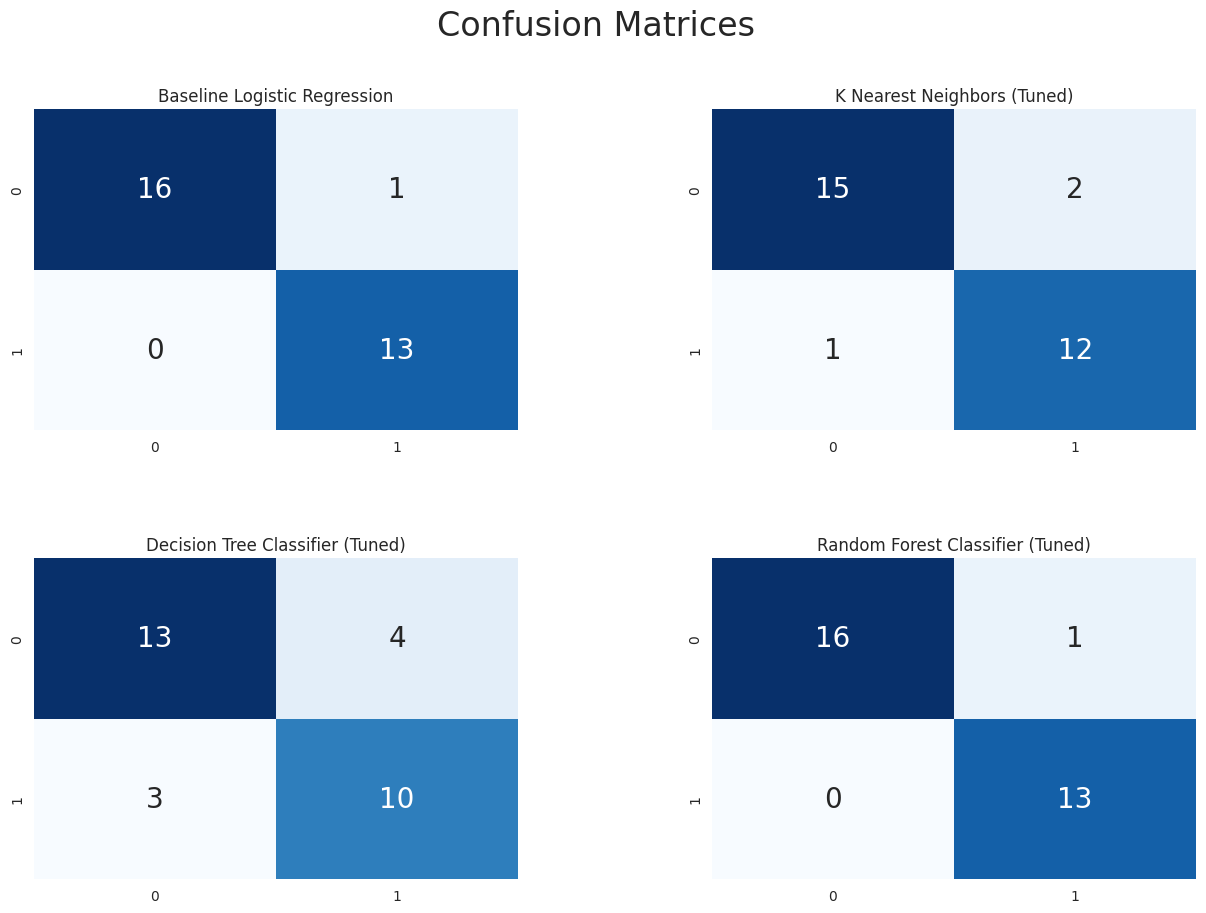

In [ ]:
# Confusion Matrices
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier # Ensure DecisionTreeClassifier is imported

# Assuming loaded_model, loaded_decision_tree_model, loaded_random_forest_model,
# and baseline_model are loaded/trained and X_test and y_test are available.

# Ensure decision_classifier is fitted before use
decision_classifier = DecisionTreeClassifier(max_depth=3) # Re-instantiate with optimal max_depth
decision_classifier.fit(x_train, y_train) # Re-fit the model

# Use the actual trained model variables
# lr is the Logistic Regression model
# knn_model is the K-Nearest Neighbors model
# decision_classifier is the Decision Tree model
# random_forest_classifier is the Random Forest model

# Make predictions using the loaded/trained models
knn_pred = knn_model.predict(x_test)
decision_tree_pred = decision_classifier.predict(x_test)
random_forest_pred = random_forest_classifier.predict(x_test)
baseline_pred = lr.predict(x_test) # Using 'lr' for baseline_model


# Confusion Matrices
cm_knn = confusion_matrix(y_test, knn_pred)
cm_decision_tree = confusion_matrix(y_test, decision_tree_pred)
cm_random_forest = confusion_matrix(y_test, random_forest_pred)
cm_baseline = confusion_matrix(y_test, baseline_pred)


# Plot Confusion Matrices
plt.figure(figsize=(15,10))
plt.suptitle("Confusion Matrices", fontsize=24)
plt.subplots_adjust(wspace = 0.4, hspace = 0.4) # Adjusted spacing

plt.subplot(2,2,1)
plt.title("Baseline Logistic Regression")
sns.heatmap(cm_baseline, annot=True, cmap="Blues", fmt="d", cbar=False, annot_kws={"size": 20})

plt.subplot(2,2,2)
plt.title("K Nearest Neighbors (Tuned)")
sns.heatmap(cm_knn, annot=True, cmap="Blues", fmt="d", cbar=False, annot_kws={"size": 20})

plt.subplot(2,2,3)
plt.title("Decision Tree Classifier (Tuned)")
sns.heatmap(cm_decision_tree, annot=True, cmap="Blues", fmt="d", cbar=False, annot_kws={"size": 20})

plt.subplot(2,2,4)
plt.title("Random Forest Classifier (Tuned)")
sns.heatmap(cm_random_forest, annot=True, cmap="Blues", fmt="d", cbar=False, annot_kws={"size": 20})

plt.show()

## Project Summary and Findings

This project aimed to predict the likelihood of heart disease based on clinical data using various machine learning classification algorithms. The key steps involved:

1.  **Data Loading and Exploration**: The dataset was loaded and explored to understand its structure, content, and identify any missing values (none were found). Basic statistics and visualizations were generated to understand the distribution of features and the target variable.
2.  **Data Preprocessing**: Categorical features were converted into dummy variables, and numerical features were scaled to prepare the data for machine learning models.
3.  **Model Building and Evaluation**: Four classification models were built and evaluated:
    *   **Logistic Regression**: Served as a baseline model.
    *   **K-Nearest Neighbors (KNN)**: Hyperparameter tuning was performed to find the optimal number of neighbors.
    *   **Decision Tree Classifier**: Hyperparameter tuning was performed to find the optimal tree depth.
    *   **Random Forest Classifier**: Hyperparameter tuning was performed to find the optimal number of estimators.
4.  **Model Comparison**: The performance of all models was compared using various metrics on the test set, including:
    *   Accuracy
    *   Precision
    *   Sensitivity (Recall)
    *   Specificity
    *   F1-Score
    *   Confusion Matrices
    *   ROC Curves and AUC

**Overall Findings:**

Based on the evaluation metrics and visualizations:

*   The **Random Forest Classifier** and **K-Nearest Neighbors (KNN)** models generally showed the best performance in terms of accuracy.
*   The **Random Forest Classifier** achieved a high precision, indicating a low rate of false positive predictions.
*   The **KNN** model demonstrated high sensitivity, suggesting it was effective at identifying actual positive cases.
*   The **Logistic Regression** model served as a reasonable baseline, and its performance highlights the improvements achieved by the other models, particularly in certain metrics.
*   The **Decision Tree Classifier**, while providing interpretability, generally had lower performance metrics compared to the ensemble methods (Random Forest) and KNN on this dataset.

The choice of the "best" model depends on the specific priorities of the application, such as whether minimizing false positives or false negatives is more critical. The Random Forest model showed a strong overall performance profile.

This project successfully demonstrated the application of various machine learning techniques for heart disease prediction, highlighting the importance of data preprocessing, model selection, hyperparameter tuning, and comprehensive evaluation for building effective predictive models.

## Conclusion on the Best Model

Based on the comprehensive evaluation of the Logistic Regression, KNN, Decision Tree, and Random Forest models using various performance metrics (Accuracy, Precision, Sensitivity, Specificity, F1-Score), confusion matrices, and ROC curves, we can conclude the following regarding the "best" model:

As discussed in the "Project Summary and Findings" (cell `6fa692f8`) and the "Interpretation of Performance Metrics Comparison" (cell `oN5jhzvbgRMV`), the choice of the best model often depends on the specific goals and priorities of the application.

*   The **Random Forest Classifier** demonstrated strong overall performance, particularly in terms of **Precision** and achieving a good balance across metrics, as reflected in its competitive **F1-Score**. Its high precision suggests it is effective at minimizing false positive predictions of heart disease.
*   The **Logistic Regression** model also showed notable strengths, particularly its high **Sensitivity (Recall)** and the highest **F1-Score** in the comparison table. This indicates it is good at identifying actual positive cases, although it had lower specificity compared to KNN and Random Forest.

Considering a balanced perspective and the importance of both identifying true cases and minimizing false alarms, both the **Random Forest Classifier** and **Logistic Regression** models are strong candidates. However, the **Random Forest Classifier's** higher precision might be preferred in scenarios where minimizing false positives is a higher priority.

The **Decision Tree Classifier** generally performed lower across most metrics compared to the other models in this analysis.

Ultimately, the "best" model is a judgment call based on which performance aspects are most critical for the deployment context. However, the analysis suggests that **Random Forest** offers a robust and well-performing solution for this heart disease prediction task.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# --- 1. Define Column Types ---
# Based on the uploaded notebook analysis and dataset structure.
NUMERICAL_FEATURES = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
CATEGORICAL_FEATURES = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
TARGET_FEATURE = 'target'

# --- 2. Data Loading and Splitting ---
def load_and_split_data(filepath='heart.csv', test_size=0.2, random_state=42):
    """Loads the dataset and splits into train/test sets."""
    print("Loading data...")
    # try:
    #     df = pd.read_csv(filepath)
    # except FileNotFoundError:
    #     print(f"Error: The file '{filepath}' was not found. Please ensure it is in the same directory.")
    #     return None, None, None, None, None, None

    # Separate features (X) and target (y)
    X = df.drop(TARGET_FEATURE, axis=1)
    y = df[TARGET_FEATURE]

    # Split the data, using stratification to maintain class balance in both sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(f"Data loaded successfully. ")
    return X, y, X_train, X_test, y_train, y_test

# --- 3. Define Preprocessing Steps using ColumnTransformer ---
def create_preprocessor(scaler_type='standard'):
    """
    Creates a ColumnTransformer for handling numerical and categorical features.

    Args:
        scaler_type (str): 'standard' for StandardScaler, 'minmax' for MinMaxScaler.
    """
    if scaler_type == 'standard':
        numeric_transformer = StandardScaler()
    elif scaler_type == 'minmax':
        numeric_transformer = MinMaxScaler()
    else:
        # Default to StandardScaler if an unexpected value is passed
        numeric_transformer = StandardScaler()

    # One-Hot Encoder for categorical features.
    # sparse_output=False ensures the output is a dense NumPy array.
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Combine transformers using ColumnTransformer to apply different transformations
    # to different subsets of features.
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, NUMERICAL_FEATURES),
            ('cat', categorical_transformer, CATEGORICAL_FEATURES)
        ],
        remainder='passthrough'
    )
    return preprocessor

# --- 4. Hyperparameter Tuning using GridSearchCV ---
def tune_pipeline_with_gridsearch(X_train, y_train):
    """
    Performs hyperparameter tuning for KNN and Random Forest using GridSearchCV
    within a pipeline context.
    """
    print("\n" + "="*50)
    print("STARTING HYPERPARAMETER TUNING (GridSearchCV)")
    print("="*50)

    # We use StratifiedKFold to ensure that the cross-validation folds maintain the target class distribution.
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 4.1. KNN Tuning Pipeline
    # KNN benefits from distance metrics, so MinMaxScaler is used.
    knn_preprocessor = create_preprocessor(scaler_type='minmax')
    knn_pipeline = Pipeline(steps=[
        ('preprocessor', knn_preprocessor),
        ('classifier', KNeighborsClassifier())
    ])

    # Define the parameter grid for KNN. Note the 'classifier__' prefix.
    knn_param_grid = {
        'classifier__n_neighbors': [5, 7, 9, 11, 13, 15],
        'classifier__weights': ['uniform', 'distance'],
        'classifier__p': [1, 2] # 1: Manhattan distance, 2: Euclidean distance
    }

    print("\n--- Tuning KNN Pipeline ---")
    knn_grid = GridSearchCV(
        knn_pipeline,
        knn_param_grid,
        cv=cv_strategy,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    knn_grid.fit(X_train, y_train)

    print(f"Best KNN parameters: {knn_grid.best_params_}")
    print(f"Best KNN cross-validation score: {knn_grid.best_score_:.4f}")

    # 4.2. Random Forest Tuning Pipeline
    # Random Forest tuning is focused on tree structure parameters.
    rf_preprocessor = create_preprocessor(scaler_type='minmax') # Scaler choice is less critical here
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Define the parameter grid for Random Forest.
    rf_param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 5, 8, None],
        'classifier__min_samples_leaf': [1, 2, 4]
    }

    print("\n--- Tuning Random Forest Pipeline ---")
    rf_grid = GridSearchCV(
        rf_pipeline,
        rf_param_grid,
        cv=cv_strategy,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    rf_grid.fit(X_train, y_train)

    print(f"Best Random Forest parameters: {rf_grid.best_params_}")
    print(f"Best Random Forest cross-validation score: {rf_grid.best_score_:.4f}")

    return {
        'KNN': knn_grid.best_estimator_,
        'Random Forest': rf_grid.best_estimator_
    }

# --- 5. Define and Evaluate Pipelines for Each Model (using best estimators) ---
def build_and_evaluate_pipelines(X_train, X_test, y_train, y_test, best_estimators=None):
    """
    Builds, trains, and evaluates a pipeline for each classifier.
    If best_estimators are provided (from GridSearchCV), they are used for KNN/RF.
    """

    # Define models (using default or pre-tuned values)
    # The untuned models are defined here to compare against the tuned versions.
    models_to_evaluate = {
        'Logistic Regression (Standard)': (LogisticRegression(max_iter=1000, random_state=42), 'standard'),
        'Decision Tree (Max Depth=3)': (DecisionTreeClassifier(max_depth=3, random_state=42), 'minmax'),
    }

    # Add tuned models to the evaluation dictionary
    models_to_evaluate['KNN (Tuned)'] = (best_estimators.get('KNN', None), 'minmax')
    models_to_evaluate['Random Forest (Tuned)'] = (best_estimators.get('Random Forest', None), 'minmax')

    results = []

    for name, (model_or_pipeline, scaler) in models_to_evaluate.items():
        if model_or_pipeline is None:
            # Skip if the tuning step failed or was skipped
            continue

        # The 'model_or_pipeline' is either a raw classifier or a complete Pipeline (if tuned)
        if isinstance(model_or_pipeline, Pipeline):
            pipeline = model_or_pipeline
            print(f"\n--- Evaluating Tuned {name} Pipeline ---")
            # No training needed, as the GridSearchCV returns a fitted pipeline.
        else:
            # Construct standard pipeline for LR and DT
            preprocessor = create_preprocessor(scaler_type=scaler)
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('classifier', model_or_pipeline)
            ])
            print(f"\n--- Training/Evaluating {name} Pipeline (Scaler: {scaler}) ---")
            pipeline.fit(X_train, y_train) # Train the standard pipeline here

        # Predict on the test set
        y_pred = pipeline.predict(X_test)
        # Predict probabilities for AUC
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        # Evaluate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, y_prob)

        # Store results
        results.append({
            "Model": name,
            "Accuracy": f"{accuracy:.4f}",
            "Precision": f"{precision:.4f}",
            "Recall": f"{recall:.4f}",
            "F1-Score": f"{f1:.4f}",
            "AUC": f"{auc:.4f}",
        })

        print(f"Test Accuracy: {accuracy:.4f} | F1-Score: {f1:.4f} | AUC: {auc:.4f}")

    # Convert results to DataFrame for clean display
    df_results = pd.DataFrame(results).set_index('Model')
    return df_results

if __name__ == '__main__':
    # Define the filepath based on the uploaded file name
    FILE_PATH = 'heart.csv'

    # 1. Load and split data
    X, y, X_train, X_test, y_train, y_test = load_and_split_data(filepath=FILE_PATH)

    if X is not None:
        # 2. Perform Hyperparameter Tuning
        tuned_models = tune_pipeline_with_gridsearch(X_train, y_train)

        # 3. Build and evaluate all pipelines, using the tuned models where available
        comparison_results = build_and_evaluate_pipelines(X_train, X_test, y_train, y_test, tuned_models)

        print("\n" + "="*50)
        print("FINAL MODEL COMPARISON (Including Tuned Models)")
        print("="*50)
        print(comparison_results)
        print("="*50)

Loading data...
Data loaded successfully. 

STARTING HYPERPARAMETER TUNING (GridSearchCV)

--- Tuning KNN Pipeline ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best KNN parameters: {'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'uniform'}
Best KNN cross-validation score: 0.8347

--- Tuning Random Forest Pipeline ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Random Forest parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 50}
Best Random Forest cross-validation score: 0.8263

--- Training/Evaluating Logistic Regression (Standard) Pipeline (Scaler: standard) ---
Test Accuracy: 0.8689 | F1-Score: 0.8824 | AUC: 0.9102

--- Training/Evaluating Decision Tree (Max Depth=3) Pipeline (Scaler: minmax) ---
Test Accuracy: 0.7213 | F1-Score: 0.7671 | AUC: 0.7662

--- Evaluating Tuned KNN (Tuned) Pipeline ---
Test Accuracy: 0.7869 | F1-Score: 0.8219 | AUC: 0.8885

--- Evaluat

In [ ]:
import joblib
joblib.dump(model, '/content/drive/MyDrive/model.pkl')

